## TASK 1 - Experimentation With Colour Spaces


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import cv2
from skimage import io, color, filters, transform, exposure
from skimage.util import img_as_float, img_as_ubyte
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

In [10]:
def part1_1_rgb_to_hsv(image_path):
    """RGB to HSV conversion and component visualization"""
    
    # 1.1.1 Import and display original image
    img = io.imread(image_path)
    if img.shape[2] == 4:  # Remove alpha channel if present
        img = img[:, :, :3]
    
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    fig.suptitle(f'RGB to HSV Conversion - {image_path.split("/")[-1]}', fontsize=14)
    
    # Display original RGB
    axes[0, 0].imshow(img)
    axes[0, 0].set_title('Original RGB')
    axes[0, 0].axis('off')
    
    # 1.1.2 Separate and display RGB components
    rgb_names = ['Red', 'Green', 'Blue']
    for i in range(3):
        component = img.copy()
        component[:, :, (i+1)%3] = 0
        component[:, :, (i+2)%3] = 0
        axes[0, i+1].imshow(component)
        axes[0, i+1].set_title(f'{rgb_names[i]} Channel')
        axes[0, i+1].axis('off')
    
    # 1.1.3 Convert to HSV
    img_hsv = color.rgb2hsv(img)
    
    # Display HSV image
    axes[1, 0].imshow(img_hsv)
    axes[1, 0].set_title('HSV (as RGB)')
    axes[1, 0].axis('off')
    
    # 1.1.4 Separate and display HSV components
    hsv_names = ['Hue', 'Saturation', 'Value']
    hsv_cmaps = ['hsv', 'gray', 'gray']
    
    for i in range(3):
        component = img_hsv[:, :, i]
        axes[1, i+1].imshow(component, cmap=hsv_cmaps[i])
        axes[1, i+1].set_title(f'{hsv_names[i]} Channel')
        axes[1, i+1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return img, img_hsv

In [14]:
image_files = ['images/images/task1/floresVermelhas.bmp', 'images/images/task1/folhasVerdes.bmp', 'images/images/task1/nenufares.bmp', 'images/images/task1/testRGB.bmp']

        
print("\n" + "="*60)
print("PART 1.1: RGB to HSV Conversion")
print("="*60)


PART 1.1: RGB to HSV Conversion



Processing images/images/task1/floresVermelhas.bmp...


AttributeError: 'str' object has no attribute 'rgb2hsv'

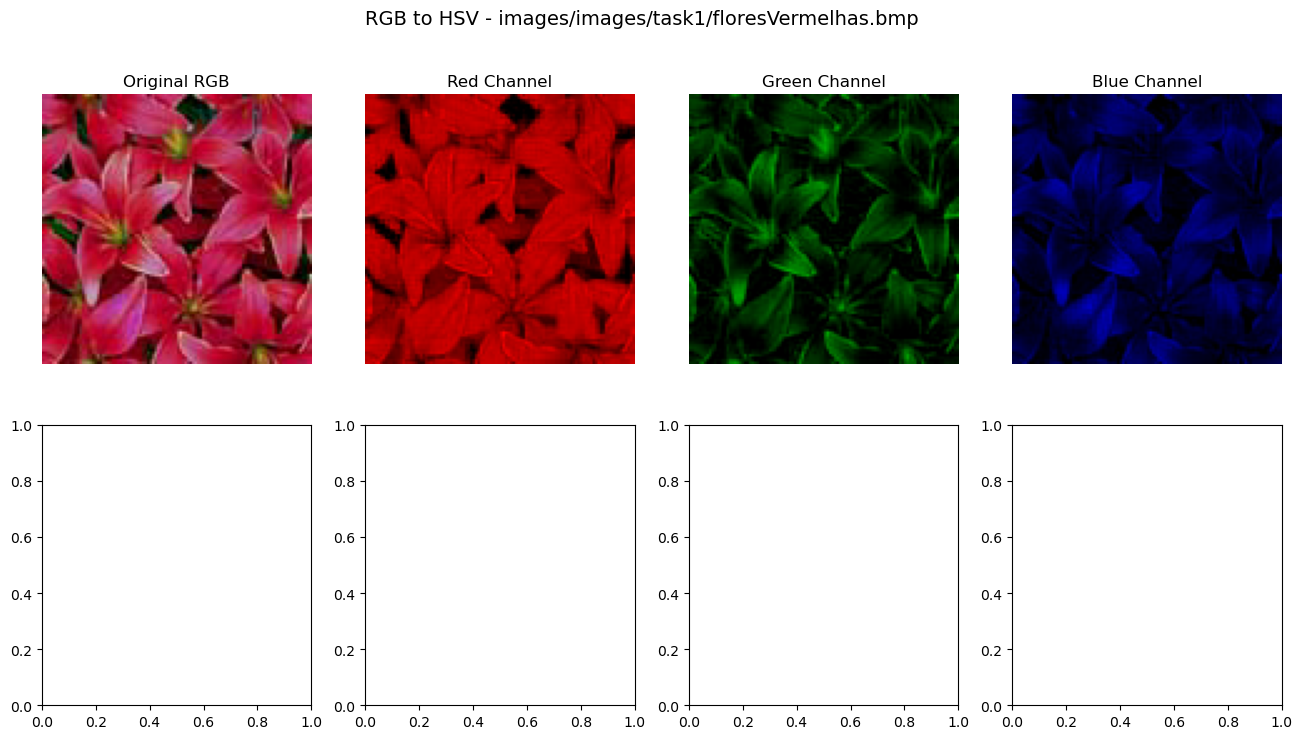

In [ ]:
# Batch RGB to HSV conversion and visualization for multiple images
from skimage import color  # Ensure color is the module, not a variable
for img_file in image_files:
    # 1.1.1 Import and display original image
    img = io.imread(img_file)
    if img.ndim == 3 and img.shape[2] == 4:  # Remove alpha channel if present
        img = img[:, :, :3]
    print(f'\nProcessing {img_file}...')
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    fig.suptitle(f'RGB to HSV - {img_file}', fontsize=14)
    # 1.1.1 Display original RGB
    axes[0, 0].imshow(img)
    axes[0, 0].set_title('Original RGB')
    axes[0, 0].axis('off')
    # 1.1.2 Separate and display RGB components
    for j, color_name in enumerate(['Red', 'Green', 'Blue']):
        component = np.zeros_like(img)
        component[:, :, j] = img[:, :, j]
        axes[0, j+1].imshow(component)
        axes[0, j+1].set_title(f'{color_name} Channel')
        axes[0, j+1].axis('off')
    # 1.1.3 Convert to HSV and display
    img_float = img_as_float(img)
    img_hsv = color.rgb2hsv(img_float)
    axes[1, 0].imshow(img_hsv)
    axes[1, 0].set_title('HSV (as RGB)')
    axes[1, 0].axis('off')
    # 1.1.4 Separate and display HSV components
    hsv_titles = ['Hue', 'Saturation', 'Value']
    hsv_cmaps = ['hsv', 'gray', 'gray']
    for j in range(3):
        axes[1, j+1].imshow(img_hsv[:, :, j], cmap=hsv_cmaps[j])
        axes[1, j+1].set_title(f'{hsv_titles[j]}')
        axes[1, j+1].axis('off')
    plt.tight_layout()
    plt.show()